# Iris Dataset

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv('iris (1).csv')

X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_model = SVC(kernel='linear')
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion Matrix (Linear):\n", confusion_matrix(y_test, y_pred_linear))


rbf_model = SVC(kernel='rbf')
rbf_model.fit(X_train, y_train)

y_pred_rbf = rbf_model.predict(X_test)

print("\nRBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Confusion Matrix (RBF):\n", confusion_matrix(y_test, y_pred_rbf))

Linear Kernel Accuracy: 1.0
Confusion Matrix (Linear):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

RBF Kernel Accuracy: 1.0
Confusion Matrix (RBF):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


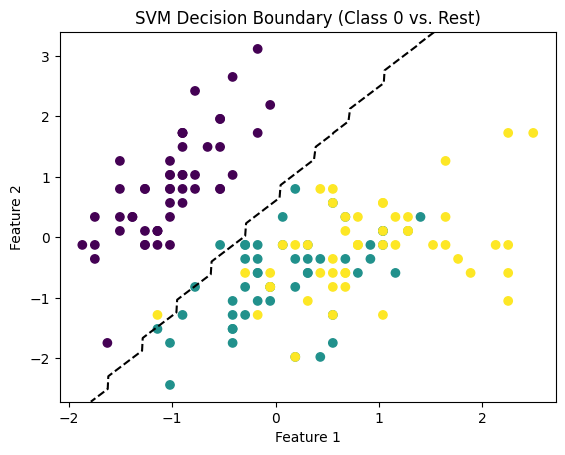

In [10]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv('iris (1).csv')

# Take only 2 features for visualization
X = df[['sepal_length', 'sepal_width']]  # adjust column names if needed
y = df['species']

# Convert labels to numeric
le = LabelEncoder()
y = le.fit_transform(y)

# Scale data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train SVM
model = svm.SVC(kernel='linear', decision_function_shape='ovr') # 'ovr' is default for n_classes > 2
model.fit(X, y)

# Plot decision boundary
def plot_svm(model, X, y):
    plt.figure()

    # Scatter plot
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')

    # Create grid
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Fix: For multi-class decision_function, it returns (n_samples, n_classes).
    # To plot a single boundary (e.g., class 0 vs. rest), select one column.
    Z = model.decision_function(xy)[:, 0].reshape(XX.shape)

    # Plot boundary
    ax.contour(XX, YY, Z, levels=[0], colors='k', linestyles='--')

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("SVM Decision Boundary (Class 0 vs. Rest)")
    plt.show()

plot_svm(model, X, y)

# Drug Dataset

In [2]:
df = pd.read_csv('drug.csv')

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

X = df.drop('Drug', axis=1)
y = df['Drug']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = SVC(kernel='rbf')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.625
Confusion Matrix:
 [[ 0  0  0  6  0]
 [ 0  0  0  3  0]
 [ 0  0  0  4  1]
 [ 0  0  0 10  1]
 [ 0  0  0  0 15]]


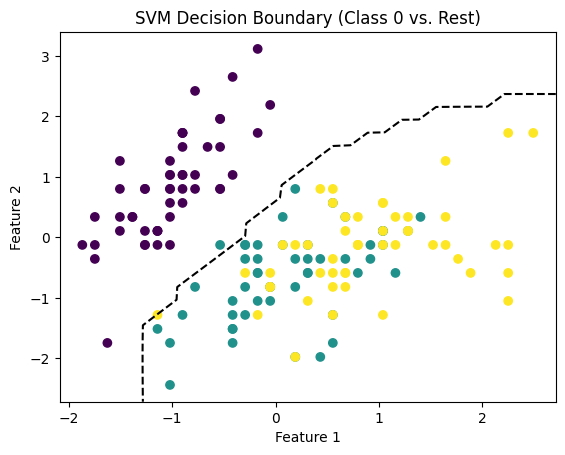

In [11]:
model = svm.SVC(kernel='rbf')
model.fit(X, y)

plot_svm(model, X, y)

# Letter Recognition dataset

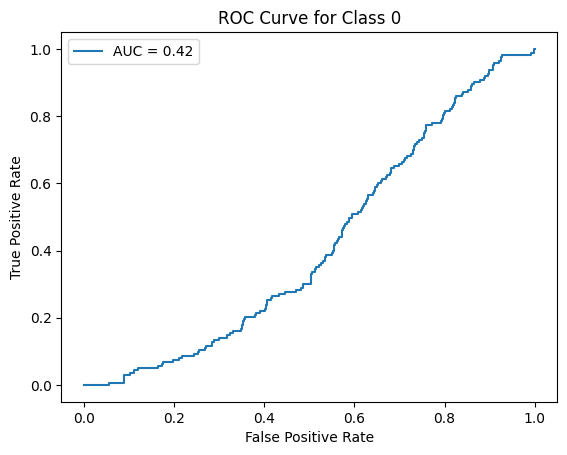

AUC Score for Class 0: 0.4181724282934488


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

df = pd.read_csv('letter-recognition.csv')

X = df.drop('letter', axis=1)
y = df['letter']

X_train, X_test, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_test_bin = label_binarize(y_test_orig, classes=y.unique())

model = SVC(kernel='rbf', probability=True)
# Fit the model with the original 1D y_train
model.fit(X_train, y_train_orig)

y_score = model.predict_proba(X_test)

# For multi-class ROC, it's common to compute one-vs-rest. We'll plot for the first class.
fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_score[:, 0])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Class 0') # Added class info to title
plt.legend()
plt.show()

print("AUC Score for Class 0:", roc_auc)